In [10]:
import pandas as pd

file_path = "../Literature Survey.xlsx"

# Skip title rows
df = pd.read_excel(file_path, skiprows=3)

# Remove row with code (-1 etc.)
df = df[df["Unnamed: 0"] != "-1"]

# Select only useful columns
clean_df = df[[
    "Unnamed: 0",
    "Self-employed in agriculture",
    "Regular wage/salaried in agriculture",
    "Casual labour in agriculture",
    "All"
]]

# Rename columns properly
clean_df.columns = [
    "State",
    "Self_Employed_Agriculture",
    "Regular_Wage_Agriculture",
    "Casual_Labour_Agriculture",
    "All_Households"
]

# Convert to numeric
for col in clean_df.columns[1:]:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# Drop missing rows
clean_df = clean_df.dropna()

print(clean_df.head())

               State  Self_Employed_Agriculture  Regular_Wage_Agriculture  \
0                 -1                         -2                        -4   
1     Andhra Pradesh                       5368                      6339   
2  Arunachal Pradesh                       5288                      6085   
3              Assam                       3677                      3236   
4              Bihar                       3694                      3027   

   Casual_Labour_Agriculture  All_Households  
0                         -6              -9  
1                       4944            5327  
2                       4629            5995  
3                       3403            3793  
4                       3327            3670  


C:\Users\Hp\AppData\Local\Temp\ipykernel_26712\2991228921.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")


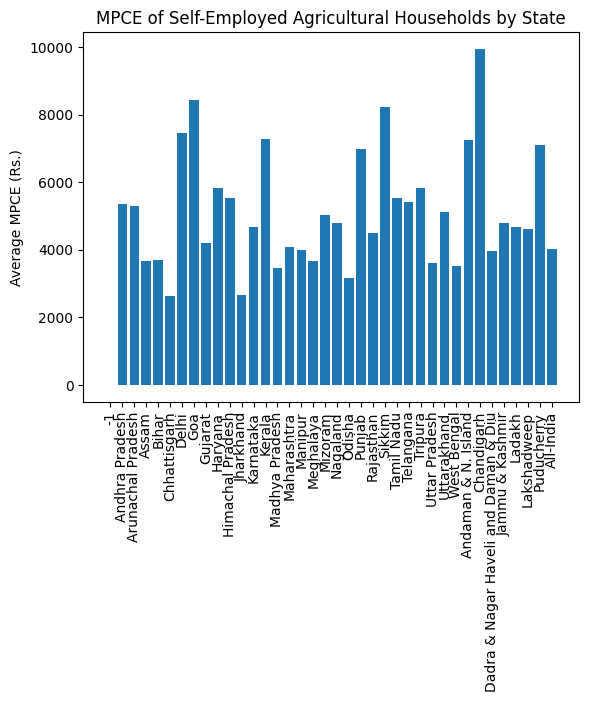

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Create numeric positions
x = np.arange(len(clean_df["State"]))

plt.figure()
plt.bar(x, clean_df["Self_Employed_Agriculture"])

plt.xticks(x, clean_df["State"], rotation=90)
plt.ylabel("Average MPCE (Rs.)")
plt.title("MPCE of Self-Employed Agricultural Households by State")

plt.show()

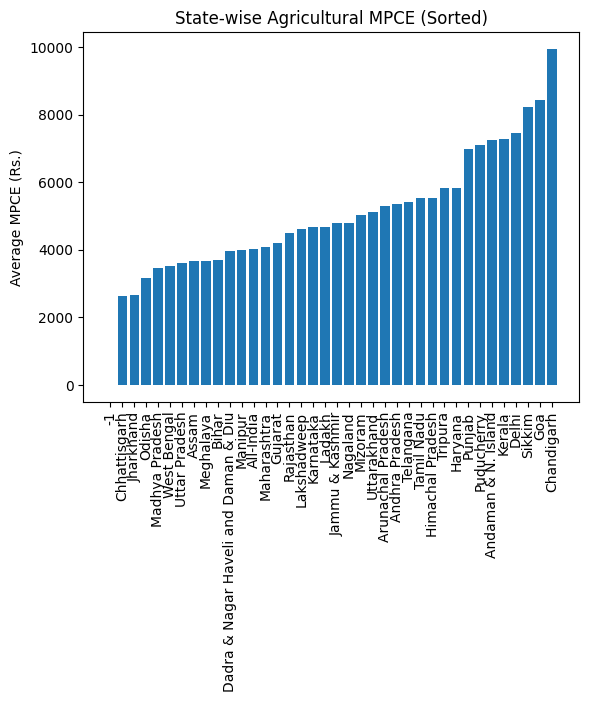

In [13]:
sorted_df = clean_df.sort_values("Self_Employed_Agriculture")

x = np.arange(len(sorted_df))

plt.figure()
plt.bar(x, sorted_df["Self_Employed_Agriculture"])
plt.xticks(x, sorted_df["State"], rotation=90)
plt.ylabel("Average MPCE (Rs.)")
plt.title("State-wise Agricultural MPCE (Sorted)")
plt.show()

In [14]:
sorted_df = clean_df.sort_values("Self_Employed_Agriculture")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sorted_df = clean_df.sort_values("Self_Employed_Agriculture")

x = np.arange(len(sorted_df))

# Create color list
colors = ["lightgray"] * len(sorted_df)

# Highlight lowest 5
for i in range(5):
    colors[i] = "black"
    

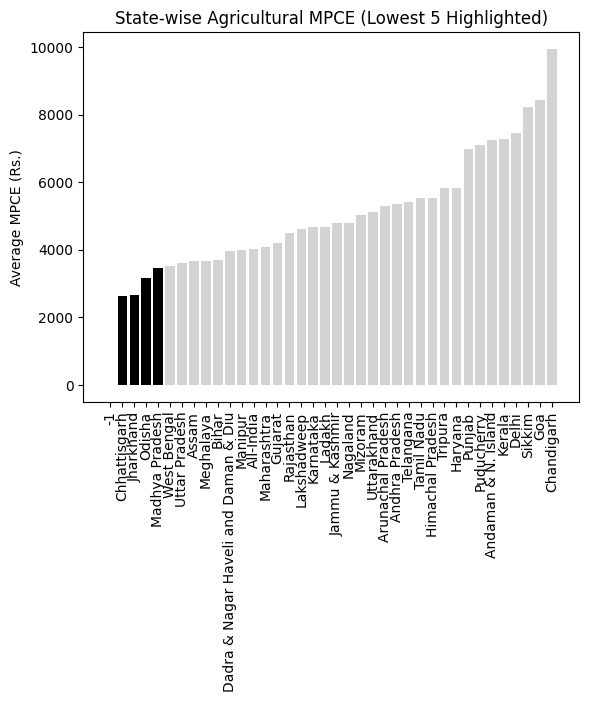

In [16]:
plt.figure()
plt.bar(x, sorted_df["Self_Employed_Agriculture"], color=colors)

plt.xticks(x, sorted_df["State"], rotation=90)
plt.ylabel("Average MPCE (Rs.)")
plt.title("State-wise Agricultural MPCE (Lowest 5 Highlighted)")

plt.show()

In [18]:
lowest_5 = sorted_df.head(6)
print("Lowest 5 States:")
print(lowest_5[["State", "Self_Employed_Agriculture"]])

Lowest 5 States:
             State  Self_Employed_Agriculture
0               -1                         -2
5     Chhattisgarh                       2622
11       Jharkhand                       2674
20          Odisha                       3181
14  Madhya Pradesh                       3470
29     West Bengal                       3522
